
## Experimental Brightfield Tomography — Acoustic Rotation of HEK Cells

This notebook demonstrates the application of the **tomographic reconstruction framework** to **real experimental data** obtained using an **acoustic rotation setup**.
The data correspond to **HEK (Human Embryonic Kidney) cells** suspended in fluid, which are **rotated acoustically** while being imaged using **brightfield microscopy**.

The experimental dataset and reference reconstruction were provided as part of the study:

> **Simon Moser, Mia Kvåle Løvmo, Franziska Strasser, Judith Hagenbuchner, Michael J. Ausserlechner, and Monika Ritsch-Marte**,
> *“Optical tomography reconstructing 3D motion and structure of multiple-scattering samples under rotational actuation,”*
> **Optica**, 12(5), 594–603 (2025).
> [https://opg.optica.org/optica/fulltext.cfm?uri=optica-12-5-594](https://opg.optica.org/optica/fulltext.cfm?uri=optica-12-5-594)

---

### **Overview**

In this example, we reconstruct and analyze a real experimental dataset to validate the robustness of our **tomography framework** under realistic imaging conditions.

The recorded data consist of:

* **2D brightfield intensity frames** captured by a microscope camera during continuous acoustic rotation.
* **Ground-truth rotation parameters** (quaternions and translations) derived from the experimental reconstruction in the Optica study.
* **Reconstructed 3D refractive index volume**, representing the internal structure of the HEK cell.

The goal is to demonstrate that the same pipeline used for simulated data (see the base *Brightfield* notebooks) can handle **experimental data directly**, with minimal modification.

---

### **Notebook Outline**

1. **Load Experimental Data**

   * Import the recorded 2D image sequence from `test_data/experimental_data/frames.npy`.
   * Display representative frames and normalize intensity.

2. **Load Ground-Truth Parameters**

   * Load quaternions (`quaternions_gt.npy`), translations (`translations_gt.npy`), and reconstructed volume (`volume_gt.npy`).

3. **Define Brightfield Imaging Model**

   * Use the same optics model as before (`setup_optics`, `imaging_model`).

4. **Forward Projection Comparison**

   * Generate forward projections of the ground-truth 3D volume using the loaded parameters.
   * Compare simulated and experimental frames.

5. **Tomographic Reconstruction**

   * Perform gradient-based optimization starting from either initial or ground-truth quaternions.
   * Reconstruct and visualize the 3D refractive index.

6. **Evaluation and Visualization**

   * Compare reconstructed volume slices to the experimental reference.
   * Plot quaternion trajectories and projection differences.

7. **Discussion**

   * Assess reconstruction quality and highlight differences between simulated and experimental imaging behavior.

---

### **Dataset Description**

| File                  | Description                                                                    |
| --------------------- | ------------------------------------------------------------------------------ |
| `frames.npy`          | Sequence of 2D brightfield microscope images captured during acoustic rotation |
| `quaternions_gt.npy`  | Ground-truth rotation parameters estimated from experimental reconstruction    |
| `translations_gt.npy` | Ground-truth translation vectors                                               |
| `volume_gt.npy`       | Reconstructed 3D refractive index map of the HEK cell                          |





[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SkariZ/TomoDpDt/blob/main/Notebooks/sum_projection_vobble.ipynb)



In [1]:
# Uncomment if you run this notebook in Google Colab
#!pip install deeplay deeptrack plotly scipy opencv-python
#!git clone https://github.com/SkariZ/TomoDpDt.git
#import sys
#sys.path.append('/content/TomoDpDt')

In [2]:
# Uncomment if running this notebook locally
#import sys
#sys.path.append('..')

In [3]:
import sys
sys.path.append('..')

import tomodpdt

import numpy as np
import time
import random

import deeplay as dl
import torch
from torch.utils.data import DataLoader

In [4]:
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEV)

Using device: cuda


## 1. Load Experimental Data

In [5]:
n_frames = 200

In [6]:
frames = np.load('../test_data/experimental_data/frames.npy')[:n_frames]

In [7]:
print('Loaded frames shape:', frames.shape)
print('Frame intensity range: [{:.2f}, {:.2f}]'.format(frames.min(), frames.max()))
print('Frames type:', frames.dtype)

Loaded frames shape: (200, 174, 200)
Frame intensity range: [-2.71-0.60j, 1.57+0.17j]
Frames type: complex64


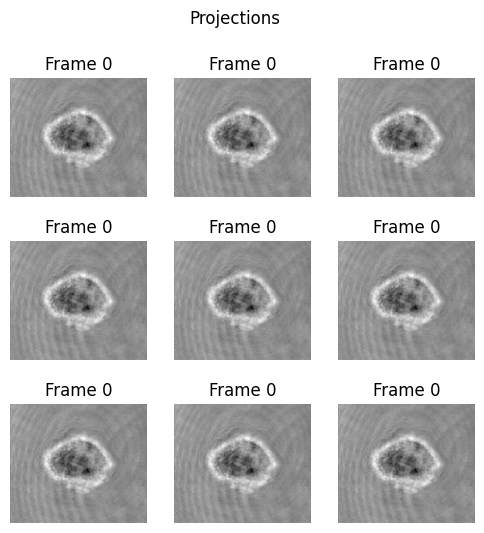

In [8]:
tomodpdt.plotting.plot_grid33_frames(np.expand_dims(frames.imag, axis=0), title="Projections", randomize=True)

## 2. Load Ground-Truth Parameters

We start by loading the ground-truth parameters, which are the quaternions, translations, and volume.

In [9]:
quaternions_gt = np.load('../test_data/experimental_data/quaternions_gt.npy')[:n_frames]
translations_gt = np.load('../test_data/experimental_data/translations_gt.npy')[:n_frames]
volume_gt = np.load('../test_data/experimental_data/volume_gt.npy')

In [10]:
print('Ground-truth quaternions shape:', quaternions_gt.shape)
print('Ground-truth translations shape:', translations_gt.shape)
print('Ground-truth volume shape:', volume_gt.shape)

Ground-truth quaternions shape: (200, 4)
Ground-truth translations shape: (200, 3)
Ground-truth volume shape: (174, 200, 150)


Using sum projections along the x, y, and z axes, we can visualize the structure of the volume...

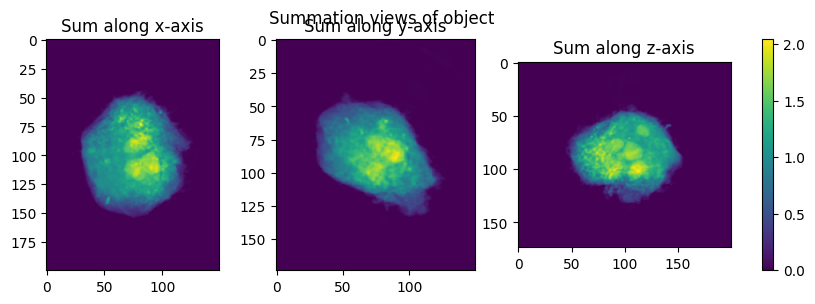

In [11]:
tomodpdt.plotting.plot_sum_object(volume_gt)

And we can inspect the ground truth quaternions as well...

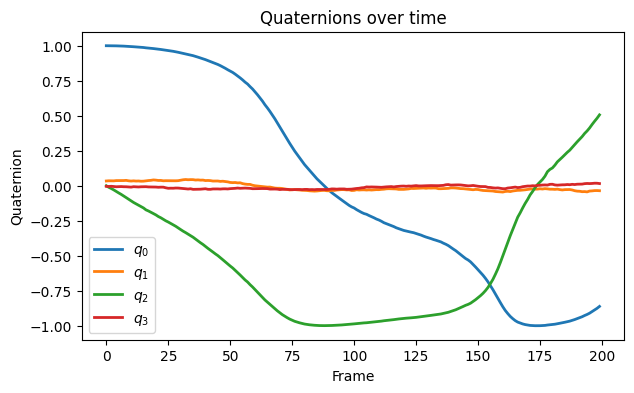

In [12]:
tomodpdt.plotting.plot_quaternions(quaternions_gt)

And we can also inspect the ground truth translations...

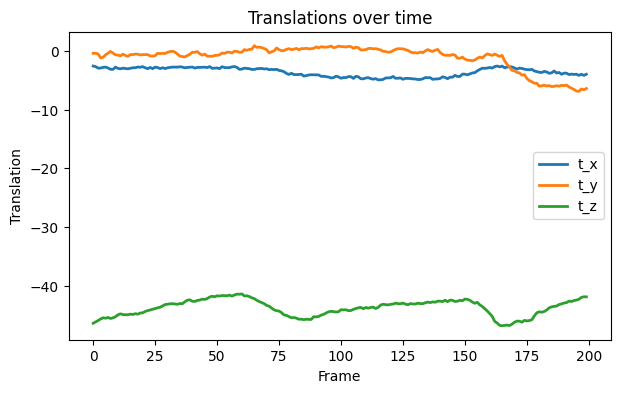

In [13]:
tomodpdt.plotting.plot_translations(translations_gt)

## 3. Define Brightfield Imaging Model

In this step, we mimic the experimental conditions by using the same parameters in our simulation.

In [14]:
from tomodpdt.imaging_modality_torch import setup_optics, imaging_model

# --- Setup the optical system ---
optics_settings = setup_optics(
    shape=volume_gt.shape,       # Shape of the 3D volume
    padding_xy=0,  # Padding in the lateral directions (avoids wrap-around effects)
    microscopy_regime='Brightfield', # Choose microscopy type: 'Brightfield', 'Fluorescence', etc.
    NA=1.15,                      # Numerical Aperture of the objective
    wavelength=640e-9,           # Illumination wavelength in meters
    resolution=200e-9,           # Effective pixel resolution in meters
    magnification=1,             # System magnification
    return_field=True            # Return the complex optical field instead of intensity only
)

# --- Build the imaging model ---
brightfield_model = imaging_model(optics_setup=optics_settings)


## 4. Forward Projection Comparison

To compare the forward projections of our ground-truth volume with the experimental frames, we can use the defined brightfield imaging model.

In [15]:
_, _, projections, imaging_model = tomodpdt.simulate.create_data(
    volume=volume_gt, # The volume we want to reconstruct
    image_modality=brightfield_model, # We use our brightfield imaging model
    translations=translations_gt[:30], # Use the ground-truth translations
    rotation_case=quaternions_gt[:30],   # Use the ground-truth orientations
    )

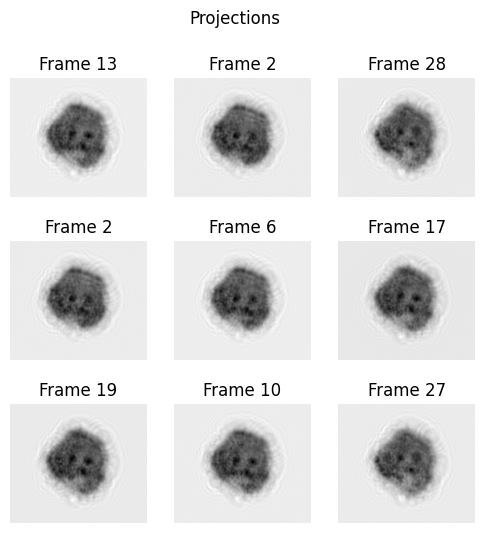

In [16]:
tomodpdt.plotting.plot_grid33_frames(projections, title="Projections", randomize=True)


In [17]:
quaternions_gt = torch.tensor(quaternions_gt, device=DEV, dtype=torch.float32)
translations_gt = torch.tensor(translations_gt, device=DEV, dtype=torch.float32)
volume_gt = torch.tensor(volume_gt, device=DEV, dtype=torch.float32)

## 4. Tomographic Reconstruction

In this section, we focus on **tomographic reconstruction**, that is, the process of recovering a 3D volume from a set of 2D projection images acquired under different viewing angles.

#### Create the tomographic model

In [18]:
tomographic_model = tomodpdt.Tomography(
    volume_size=volume_gt.shape, # The size of the volume
    initial_volume='zeros', # 'refraction' since we are optimizing the refractive index
    rotation_optim_case='quaternion', # 'basis' or 'quaternion', 'basis' is smoother
    imaging_model=brightfield_model, # The imaging model
    automatic_optimization=False, # We will handle optimization manually
    )

Let us start by removing the global phase offset...

In [19]:
frames = torch.tensor(frames * np.exp(-1j * np.angle(frames[:, :20, :20]).mean(axis=(1,2), keepdims=True)), requires_grad=False, device=DEV)
frames = torch.stack([frames.real, frames.imag], axis=1)

In [20]:
print('Frames shape for optimization:', frames.shape)

Frames shape for optimization: torch.Size([200, 2, 174, 200])


#### Initialize the parameters

In [21]:
tomographic_model.initialize_parameters(frames, normalize=False, max_epochs=200, peaks_period_range=[80, 220])

c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name                | Type                 | Params | Mode 
---------------------------------------------------------------------
0 | encoder             | Sequential           | 79.8 K | train
1 | fc_mu               | MultiLayerPerceptron | 73.8 K

Epoch 199: 100%|██████████| 7/7 [00:00<00:00, 51.95it/s, v_num=1948, train_rec_loss_step=0.141, train_KL_step=67.90, train_total_loss_step=0.141, train_rec_loss_epoch=0.139, train_KL_epoch=247.0, train_total_loss_epoch=0.141]  
✅ Rotation initialization from latent space successful.


For vizualisation we initialize a `TomoPlotter` class for easier plotting.

In [22]:
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)

#### Visualizing the Latent Space Trajectory, Peaks and the Initial Guess


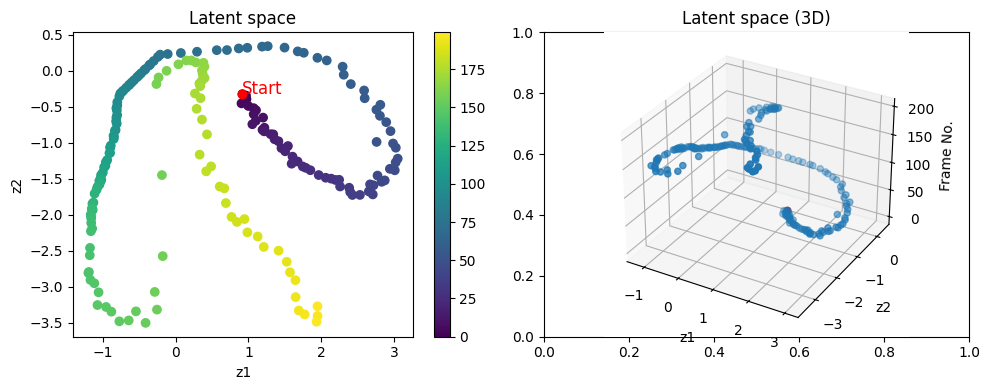

In [23]:
plotter.plot_latent_space()

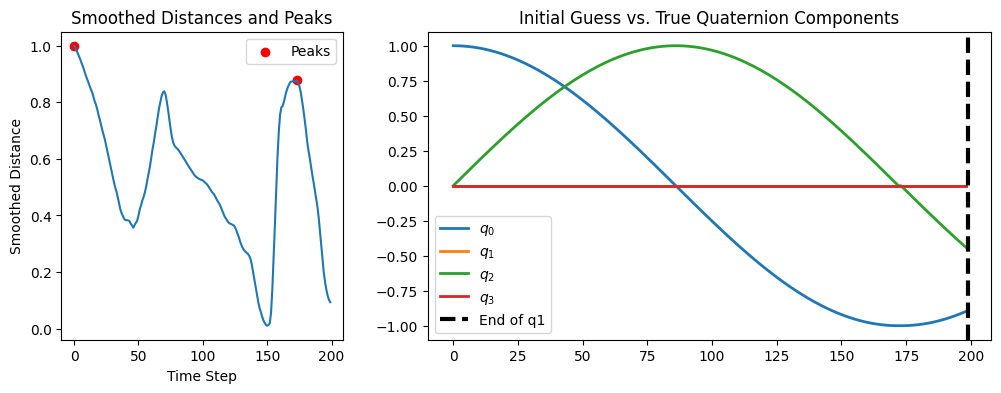

In [24]:
plotter.plot_smooth_dist_intial_guess()

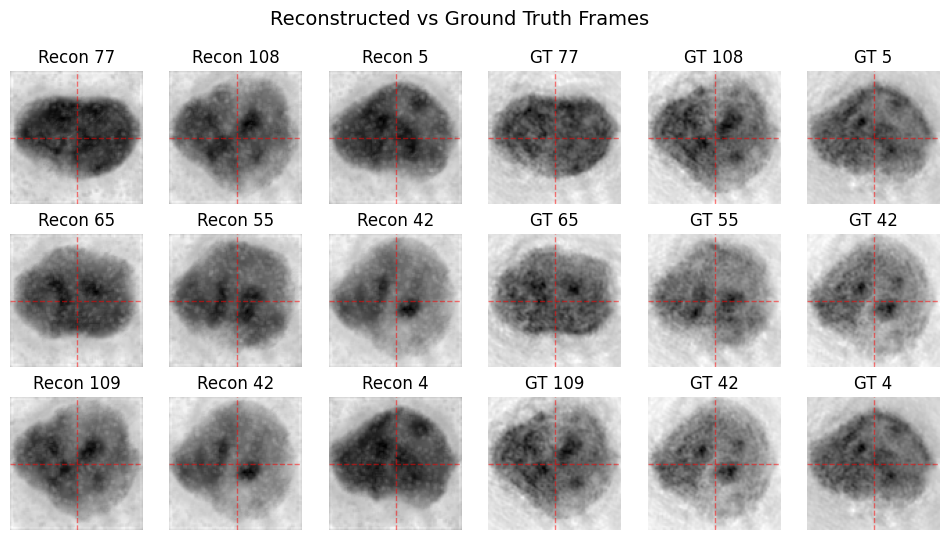

In [25]:
plotter.plot_reconstructed_vs_gt()


### 4.1 Start the 3D Reconstruction Optimization


In [26]:
N1 = len(tomographic_model.frames) # Number of frames
idx = torch.arange(N1) # List of indexes
epochs_object_only = 20 # Number of epochs for the object only optimization
batch_size_object_only = 32 # Batch size for the object only optimization

In [27]:
# Toggle the gradients of the quaternion parameters to False
tomographic_model.toggle_gradients_quaternion(False)

# Toggle the gradients of the translation parameters to False
tomographic_model.toggle_gradients_translation(False)

# Move the model to device and all parameters
tomographic_model.move_all_to_device(DEV)

In [28]:
# Train the model
start_time = time.time()
trainer = dl.Trainer(max_epochs=epochs_object_only, accelerator="auto", log_every_n_steps=10)
trainer.fit(tomographic_model, DataLoader(idx, batch_size=batch_size_object_only , shuffle=True))
print("Training time: ", (time.time() - start_time) / 60, " minutes")

c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\core\optimizer.py:317: The lr scheduler dict contains the key(s) ['monitor'], but the keys will be ignored. You need to call `lr_scheduler.step()` manually in manual optimization.

  | Name          | Type                   | Params | Mode 
-----------------------------------------------------------------
0 | vae_model     | VariationalAutoEncoder | 403 K  | train
1 | encoder       | Sequential             | 79.8 K | train
2 | fc_mu         | MultiLayerPerceptron   | 73.8 K | train
3 | imaging_model | imaging_model          | 0      | train
4 | train_metrics | MetricCollection       | 0      | train
5 | val_metrics   | MetricCollection       | 0      | train
6 | test_metrics  | MetricCollection       | 0      | train
7 | optimizer     | Adam                   | 0      | train
  | other params  | n/a                    | 5.1 M  | n/a  
-----------------------------------------------------------------
5.2 M  

Epoch 19: 100%|██████████| 6/6 [00:12<00:00,  0.48it/s, v_num=1949, train_total_loss_step=0.0685, train_proj_loss_step=0.0677, train_rtv_loss_step=0.000861, train_total_loss_epoch=0.0718, train_proj_loss_epoch=0.0709, train_rtv_loss_epoch=0.000856]
Training time:  4.18886395295461  minutes


### 4.2 Optimize the 3D volume and the rotation parameters

In [29]:
epochs_object_rot = 200 # Number of epochs for the object and rotation optimization
batch_size_object_rot = 16 # Batch size for the object and rotation optimization

In [30]:
# Toggle the gradients of the quaternion parameters
tomographic_model.toggle_gradients_quaternion(True)

# The gradients of the translation parameters are already False and remain so since we do not want to optimize them now
tomographic_model.toggle_gradients_translation(True)

# Move the model to device
tomographic_model.move_all_to_device(DEV)

and train the model for `epochs_object_rot` epochs...


  | Name          | Type                   | Params | Mode 
-----------------------------------------------------------------
0 | vae_model     | VariationalAutoEncoder | 403 K  | train
1 | encoder       | Sequential             | 79.8 K | train
2 | fc_mu         | MultiLayerPerceptron   | 73.8 K | train
3 | imaging_model | imaging_model          | 0      | train
4 | train_metrics | MetricCollection       | 0      | train
5 | val_metrics   | MetricCollection       | 0      | train
6 | test_metrics  | MetricCollection       | 0      | train
7 | optimizer     | Adam                   | 0      | train
  | other params  | n/a                    | 5.1 M  | n/a  
-----------------------------------------------------------------
5.2 M     Trainable params
403 K     Non-trainable params
5.6 M     Total params
22.501    Total estimated model params size (MB)
83        Modules in train mode
0         Modules in eval mode
c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\py

Epoch 199: 100%|██████████| 11/11 [00:25<00:00,  0.44it/s, v_num=1950, train_total_loss_step=0.0513, train_proj_loss_step=0.0484, train_rtv_loss_step=0.00117, train_rtr_loss_step=0.00174, train_total_loss_epoch=0.0538, train_proj_loss_epoch=0.0509, train_rtv_loss_epoch=0.00117, train_rtr_loss_epoch=0.00174] 
Training time:  82.83778140147527  minutes


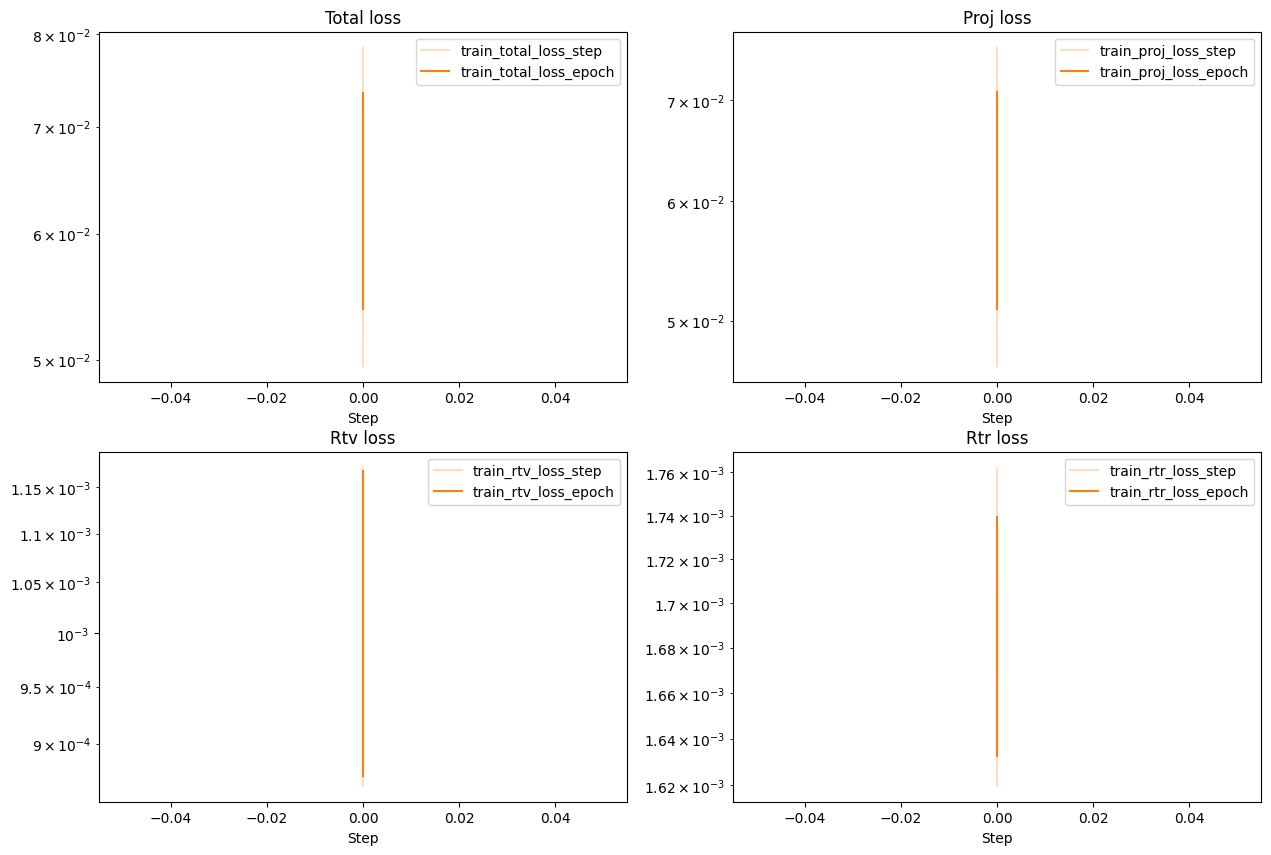

In [31]:
# Train the model
start_time = time.time()
trainer = dl.Trainer(max_epochs=epochs_object_rot, accelerator="auto", log_every_n_steps=None)
trainer.fit(tomographic_model, DataLoader(idx, batch_size=batch_size_object_rot , shuffle=True))
print("Training time: ", (time.time() - start_time) / 60, " minutes")

# Plot the training history
try:
    trainer.history.plot()
except:
    print("No history to plot...")

## 6.  Evaluate & Visualize

In [32]:
# Move it to the GPU if possible for faster plotting
tomographic_model.move_all_to_device(DEV)

# Visualize the final volume and rotations.
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)

quaternions_gt = quaternions_gt[:len(tomographic_model.frames)]
translations_gt = translations_gt[:len(tomographic_model.frames)]

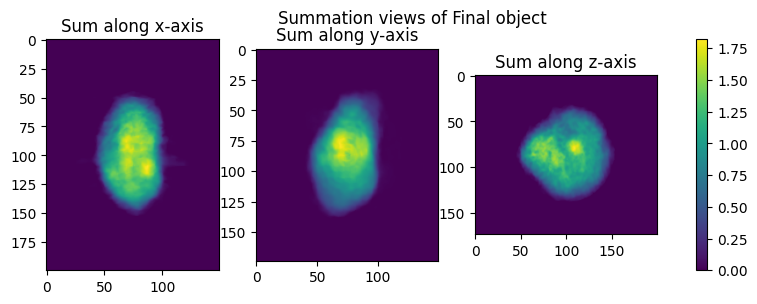

In [33]:
plotter.plot_sum_object(save_name="Final object")

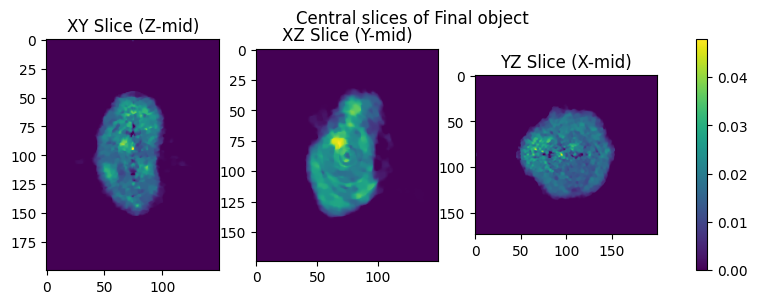

In [34]:
plotter.plot_slice_object(save_name="Final object")

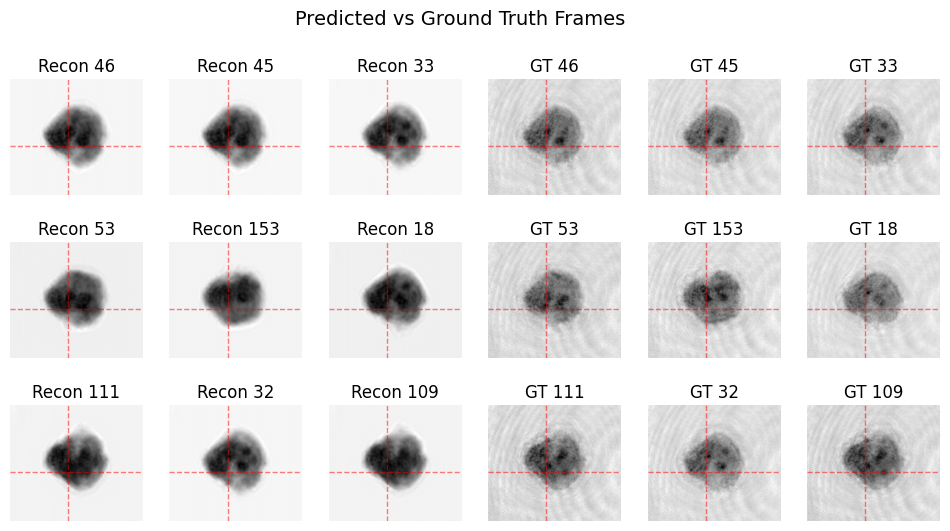

In [35]:
plotter.plot_reconstructed_vs_gt(column_headers=["Predicted", "Ground Truth"], forward=True, save_name="Reconstructed vs GT")

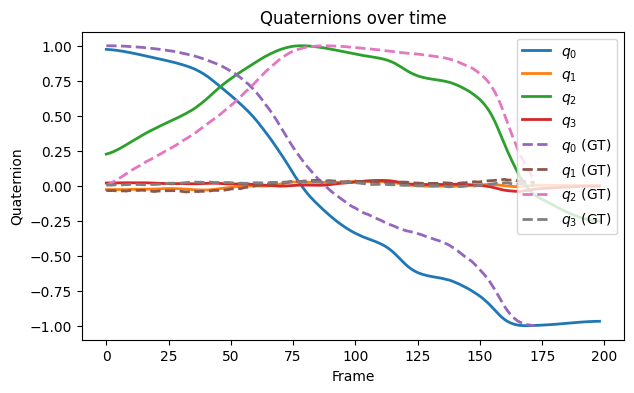

In [ ]:
# Switching the sign of the quaternions
quaternions_gt[:, 1:] = -quaternions_gt[:, 1:]

# Plot the ground truth quaternions
plotter.plot_quaternions(q_gt=quaternions_gt, save_name="Quaternions comparison")

In [37]:
#plotter.plot_translations(t_gt=translations_gt)

In [42]:
tomographic_model.move_all_to_device(DEV)
idx = np.random.randint(0, len(tomographic_model.frames), 10)

forward_projections = tomographic_model.full_forward_final(max_projections=10, idx=idx)

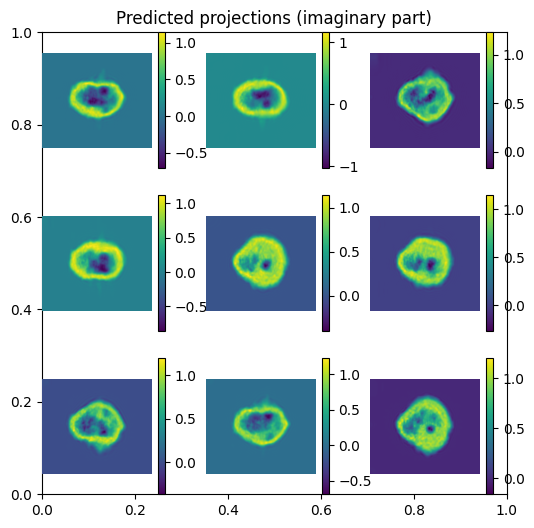

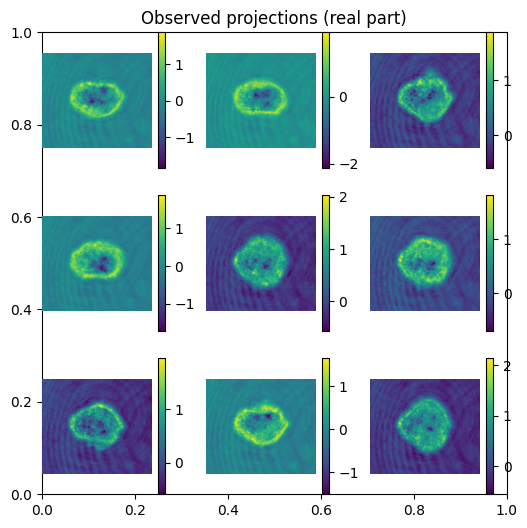

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.title("Predicted projections (imaginary part)")
for i in range(9):
    proj_upd = forward_projections[i, 1].detach().cpu().numpy()
    plt.subplot(3, 3, i + 1)
    plt.imshow(proj_upd)
    plt.colorbar()
    plt.axis('off')
plt.show()

"""""
plt.figure(figsize=(6, 6))
plt.title("Predicted projections (real part)")
for i in range(9):
    proj_upd = forward_projections[i, 0].detach().cpu().numpy()
    plt.subplot(3, 3, i + 1)
    plt.imshow(proj_upd)
    plt.colorbar()
    plt.axis('off')
plt.show()
"""

# show projections
plt.figure(figsize=(6, 6))
plt.title("Observed projections (Imaginary part)")
for i, idx_ in enumerate(idx):
    if i >= 9:
        break
    proj_upd = tomographic_model.frames[idx_].detach().cpu().numpy()
    plt.subplot(3, 3, i + 1)
    plt.imshow(proj_upd[1])
    plt.colorbar()
    plt.axis('off')
plt.show()

The most effective way to visualize and compare the reconstructed volume to the ground truth is through interactive 3D plots using `plotly`.

In [44]:
# Uncomment belowto visualize the 3D volume
# tomodpdt.plotting.visualize_3d_volume(tomographic_model.volume.detach().cpu(), save_name="Final object 3D")
# tomodpdt.plotting.visualize_3d_volume(test_object.cpu(), save_name="Ground truth object 3D")

## 7. Save Result

Once the process is complete, we can save the reconstructed volume and the quaternion parameters to `numpy` arrays.

In [45]:
# Define where to save the reconstruction results
# save_folder = "path/to/save/folder"

# --- Save the reconstructed 3D volume ---
# Extract the optimized volume from the model and save as a NumPy array
# volume = tomographic_model.get_volume().detach().cpu().numpy()
# np.save(f"{save_folder}/volume.npy", volume)

# --- Save the optimized quaternions ---
# Extract the final quaternion parameters and save them as a NumPy array
# quaternions_pred = tomographic_model.get_quaternions_final().detach().cpu().numpy()
# np.save(f"{save_folder}/quaternions.npy", quaternions_pred)

